In [2]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up paths to match your cluster environment
BASE_DIR = Path("/share/home/e2406751/Superresolution-TIR/data/processed/seq_patches")

def plot_vsr_sequence(split="train", sequence_name=None):
    """
    Loads and plots a 5-frame VSR sequence showing HR and LR side-by-side.
    If sequence_name is None, it selects one randomly from the split folder.
    """
    hr_root = BASE_DIR / split / "HR"
    
    # 1. Grab sequence names
    available_sequences = sorted([d.name for d in hr_root.iterdir() if d.is_dir()])
    if not available_sequences:
        print(f"No sequences found in: {hr_root}")
        return
    
    # 2. Selection logic
    if sequence_name is None:
        sequence_name = random.choice(available_sequences)
    elif sequence_name not in available_sequences:
        print(f"Requested sequence '{sequence_name}' not found. Available samples: {available_sequences[:5]}...")
        return
        
    print(f"Visualizing Target Group: {sequence_name} | Split: {split.upper()}")
    
    # 3. Initialize Matplotlib Plotting Grid
    # Row 0 = HR Frames, Row 1 = LR Frames across the 5-frame tracking timeline
    fig, axes = plt.subplots(3, 5, figsize=(16, 9))
    
    for frame_idx in range(5):
        # Build path signatures using Resolution-First layout rules
        hr_frame_path = BASE_DIR / split / "HR" / sequence_name / f"{frame_idx:04d}.npy"
        lr_frame_path = BASE_DIR / split / "LR" / sequence_name / f"{frame_idx:04d}.npy"
        wm_frame_path = BASE_DIR / split / "WM" / sequence_name / f"{frame_idx:04d}.npy"
        
        # Load raw numpy arrays from disk
        hr_matrix = np.load(hr_frame_path)
        lr_matrix = np.load(lr_frame_path)
        wm_matrix = np.load(wm_frame_path)
        
        # Plot High-Resolution Track
        ax_hr = axes[0, frame_idx]
        im_hr = ax_hr.imshow(hr_matrix, cmap="inferno") # Thermal map representation
        ax_hr.set_title(f"HR Frame {frame_idx}\n{hr_matrix.shape}", fontsize=10)
        ax_hr.axis("off")
        
        # Plot Low-Resolution Track
        ax_lr = axes[1, frame_idx]
        im_lr = ax_lr.imshow(lr_matrix, cmap="inferno")
        ax_lr.set_title(f"LR Frame {frame_idx}\n{lr_matrix.shape}", fontsize=10)
        ax_lr.axis("off")
        
        # Plot Water Mask
        ax_wm = axes[2, frame_idx]
        im_wm = ax_wm.imshow(wm_matrix, cmap="Blues")
        ax_wm.set_title(f"WM Frame {frame_idx}\n{wm_matrix.shape}", fontsize=10)
        ax_wm.axis("off")

    plt.suptitle(f"Downstream VSR Sequence Integrity Check: {sequence_name}", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


Visualizing Target Group: BAS_2025_b0_r0_c1152 | Split: TRAIN


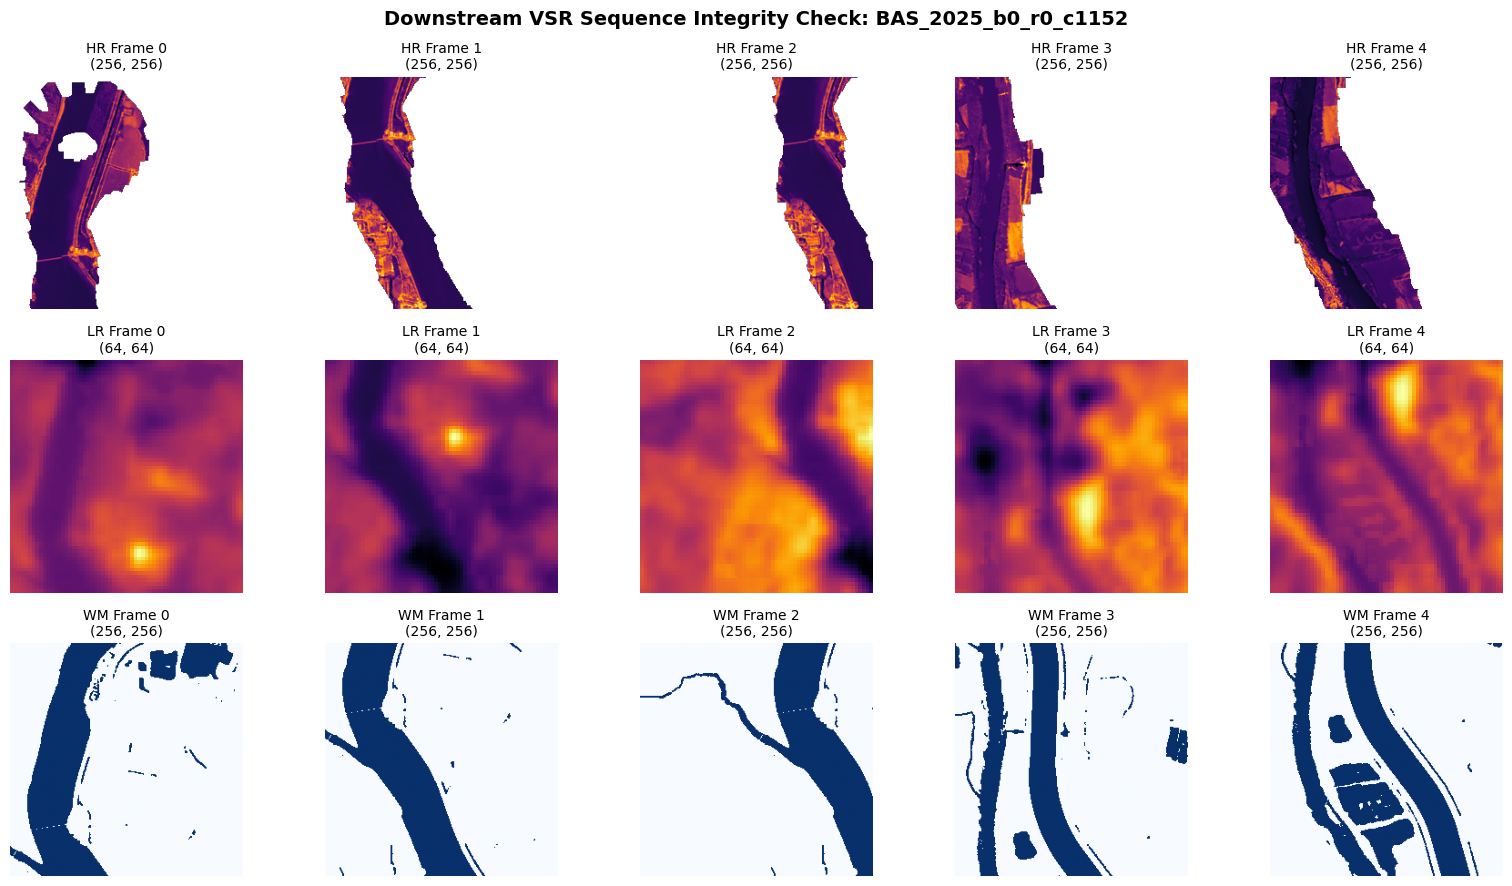

In [5]:
# Execute verification step inside the notebook cell
plot_vsr_sequence(split="train")

Visualizing Target Group: DZM_2013_b1_r2304_c0 | Split: VAL


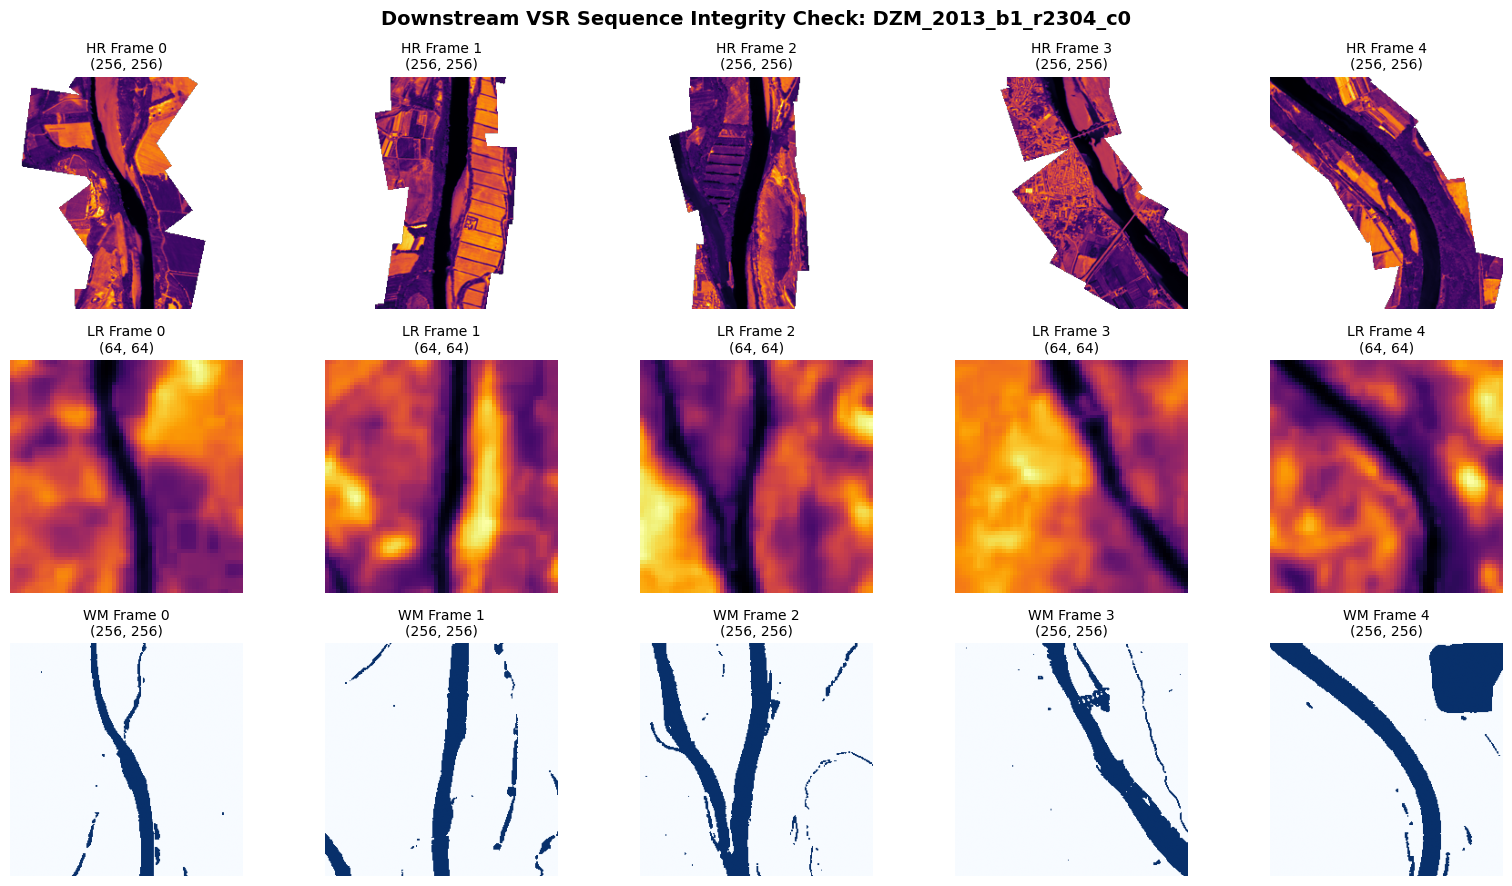

In [8]:
# Execute verification step inside the notebook cell
plot_vsr_sequence(split="val")

Visualizing Target Group: BRC_2023_b0_r0_c0 | Split: TEST


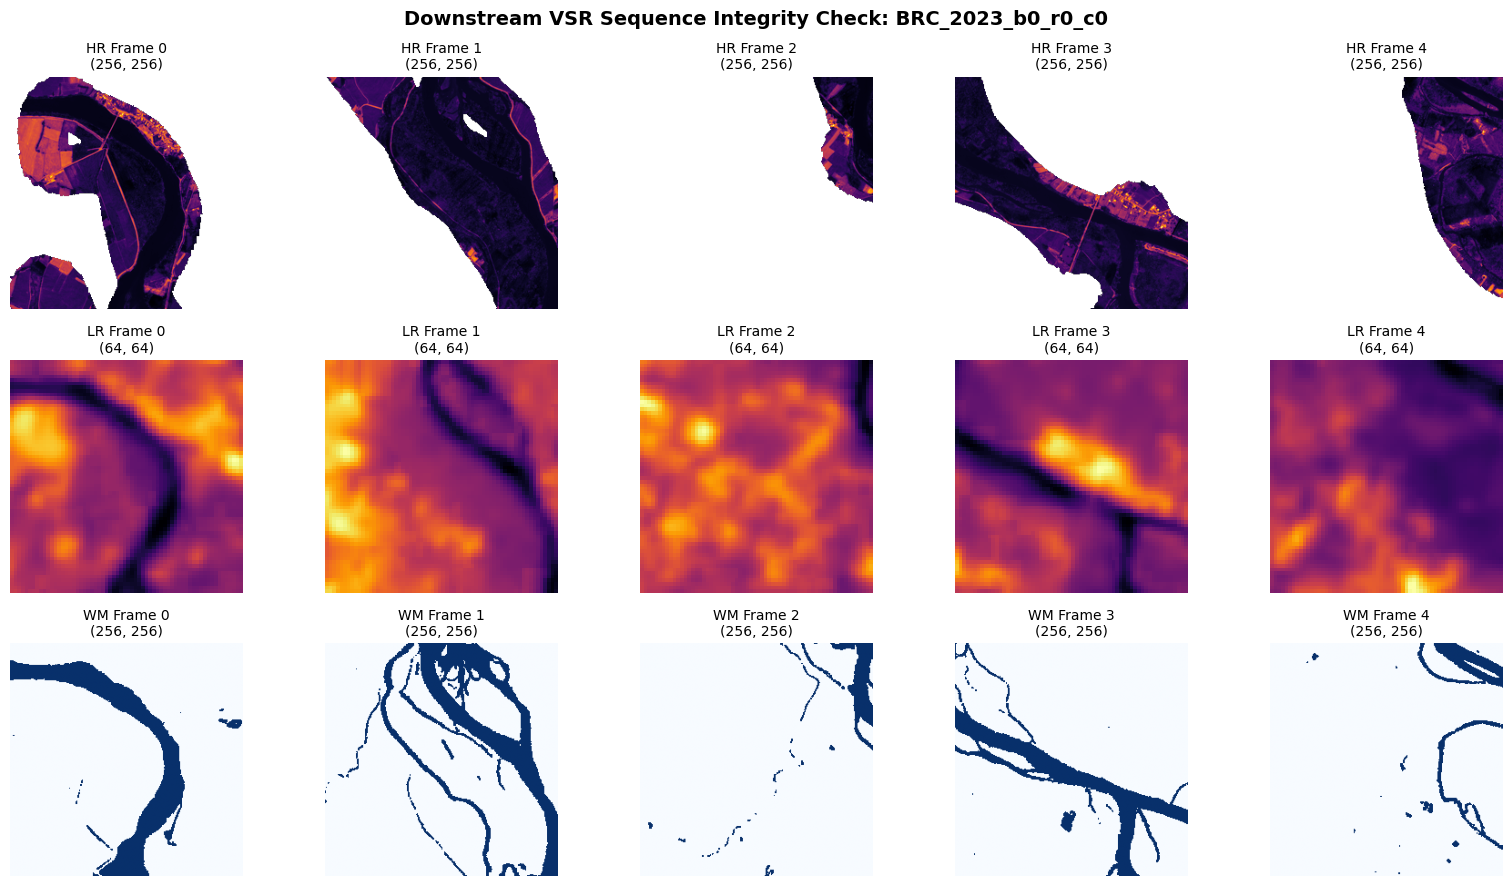

In [16]:
# Execute verification step inside the notebook cell
plot_vsr_sequence(split="test")

### TIME GAP UPDATE ON METADATA   
DO NOT DELETE

In [2]:
import json
from pathlib import Path
from datetime import datetime, timedelta

# 1. Define the path here
BASE_DIR = Path("/share/home/e2406751/Superresolution-TIR/data/processed/seq_patches")
METADATA_PATH = BASE_DIR / "metadata.json"

# CAMPAIGN_DATA as you provided
CAMPAIGN_DATA = {
    "PDR_2023": {"air_time": "11:24-12:43", "sat_time": "10:22-10:23"},
    "DZM_2023": {"air_time": "11:35-12:19", "sat_time": "10:29-10:30"},
    "BRC_2023": {"air_time": "11:48-12:57", "sat_time": "10:22-10:23"},
    "BRC_2022": {"air_time": "12:07-13:14", "sat_time": "10:23-10:24"},
    "DZM_2019": {"air_time": "15:40-16:30", "sat_time": "10:23-10:24"},
    "PDR_2013": {"air_time": "17:47-18:18", "sat_time": "10:25-10:26"},
    "PDR_2014": {"air_time": "16:06-16:31", "sat_time": "10:23-10:24"},
    "DZM_2013": {"air_time": "14:40-15:15", "sat_time": "10:25-10:26"},
    "DZM_2014": {"air_time": "15:40-16:00", "sat_time": "10:29-10:30"},
    "BAS_2025": {"air_time": "15:02-16:37", "sat_time": "10:29-10:30"},
    "HAUT_2025": {"air_time": "14:43-16:21", "sat_time": "10:22-10:23"}
}

def get_avg_time_decimal(time_str):
    """Parses 'HH:MM-HH:MM' and returns decimal hours."""
    start, end = [datetime.strptime(t, "%H:%M") for t in time_str.split('-')]
    if end < start: end += timedelta(days=1)
    avg = start + (end - start) / 2
    return round(avg.hour + avg.minute / 60.0, 2)

def get_time_gap(air_time_str, sat_time_str):
    """Calculates gap in hours between two HH:MM-HH:MM ranges."""
    def to_dt(ts):
        start, end = [datetime.strptime(t, "%H:%M") for t in ts.split('-')]
        if end < start: end += timedelta(days=1)
        return start + (end - start) / 2
    
    delta = abs((to_dt(air_time_str) - to_dt(sat_time_str)).total_seconds()) / 3600.0
    return round(delta, 2)

def update_metadata(metadata_path):
    # 1. Load the data
    with open(metadata_path, 'r') as f:
        meta = json.load(f)
    
    # 2. Iterate and update
    updated_count = 0
    for key, info in meta.items():
        camp = info.get("campaign") # Use .get() to avoid KeyError if field missing
        
        if camp in CAMPAIGN_DATA:
            cfg = CAMPAIGN_DATA[camp]
            
            # Date conversion
            d1 = datetime.strptime(info["hr_date"], "%Y-%m-%d")
            d2 = datetime.strptime(info["lr_date"], "%Y-%m-%d")
            info["date_gap_days"] = abs((d1 - d2).days)
            
            # Time calculations
            info["time_gap_hours"] = get_time_gap(cfg["air_time"], cfg["sat_time"])
            info["hr_time"] = get_avg_time_decimal(cfg["air_time"])
            info["lr_time"] = get_avg_time_decimal(cfg["sat_time"])
            
            updated_count += 1
        # else:
        #     print(f"DEBUG: Campaign '{camp}' found in key {key} but not in CAMPAIGN_DATA.")
            
    # 3. Save the result
    with open(metadata_path, 'w') as f:
        json.dump(meta, f, indent=4)
        
    print(f"Success! Updated {updated_count} frames.")

update_metadata(METADATA_PATH)

Success! Updated 1750 frames.


### Inference

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader

import os
import sys
import json


BASE = Path("/share/home/e2406751/Superresolution-TIR")
sys.path.insert(0, str(BASE))

PATCHES_DIR = BASE / "data/processed/seq_patches"
METADATA_PATH = PATCHES_DIR / "metadata.json"
STATS_PATH  = BASE / "data/processed/patches/stats.json"
with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]
DATA_MIN   = stats_data["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [15]:
from scripts.utils.seq_dataset import SRDataset
from scripts.models.basicvsrplus import BasicVSRModule

CHECKPOINT = (BASE /"checkpoints/vsr/exp3_epoch=41_val_water_mae=1.3235.ckpt")
model = BasicVSRModule.load_from_checkpoint(CHECKPOINT,map_location=device, strict=False).to(device).eval()


[INFO] SpyNet: loaded after remapping mmediting key layout.
[WARNING] SpyNet: 2 missing keys (first 5: ['mean', 'std'])
[INFO] BasicVSR++ backbone: loaded after stripping 'generator.' prefix.
[INFO] BasicVSR++ backbone: loaded after remapping mmediting key layout.
[INFO] BasicVSR++ backbone loaded cleanly, no missing/unexpected keys.


Number of validation sequences: 23
LR: torch.Size([1, 5, 3, 64, 64])
HR: torch.Size([1, 5, 3, 256, 256])
HR Mask: torch.Size([1, 5, 1, 256, 256])


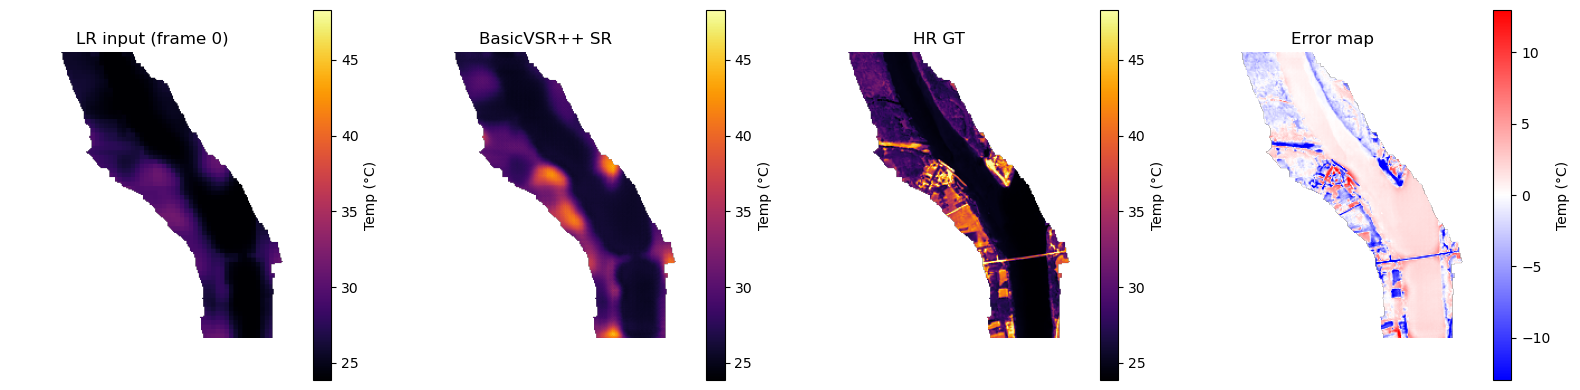

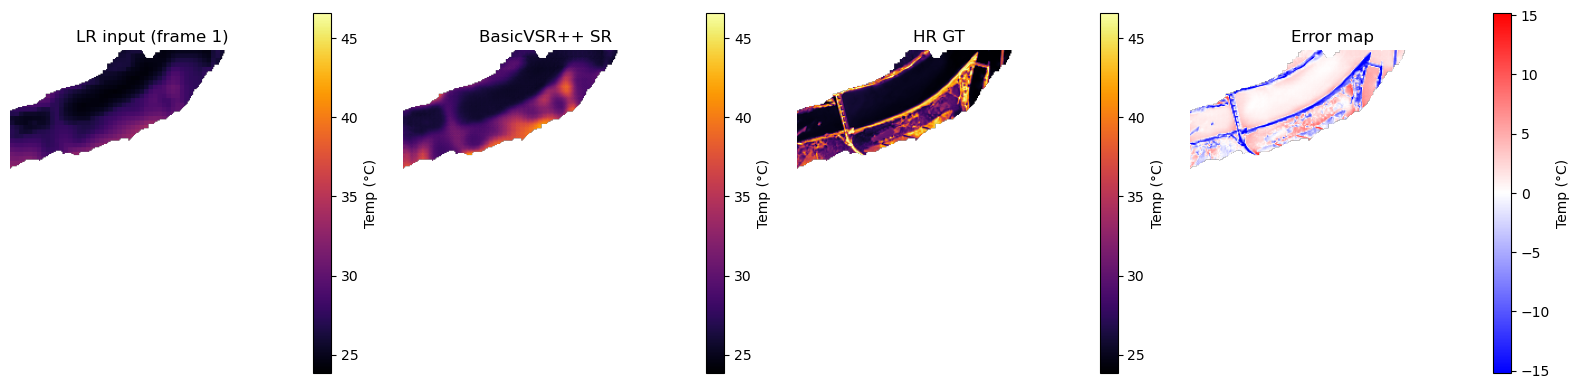

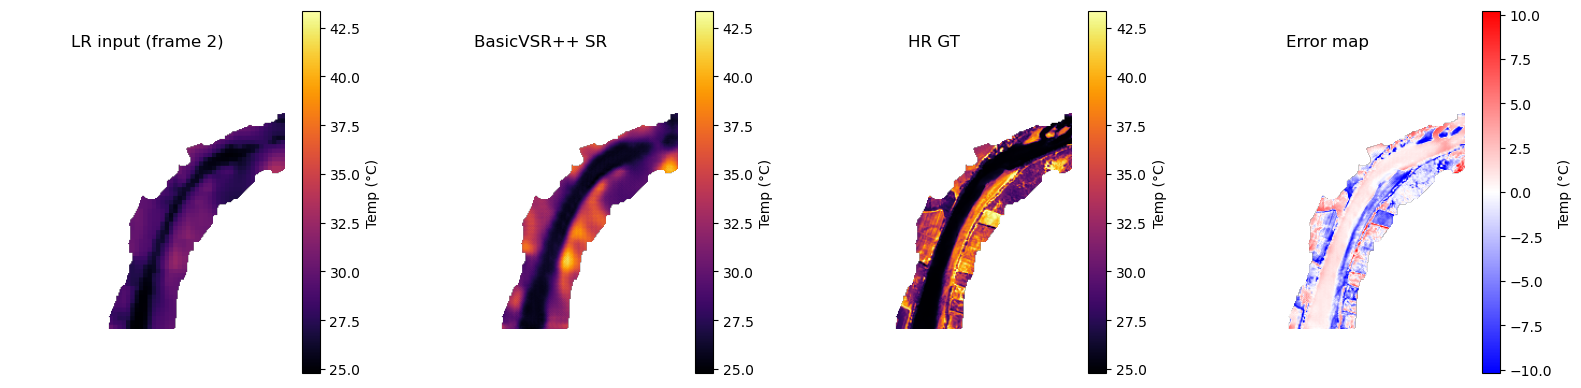

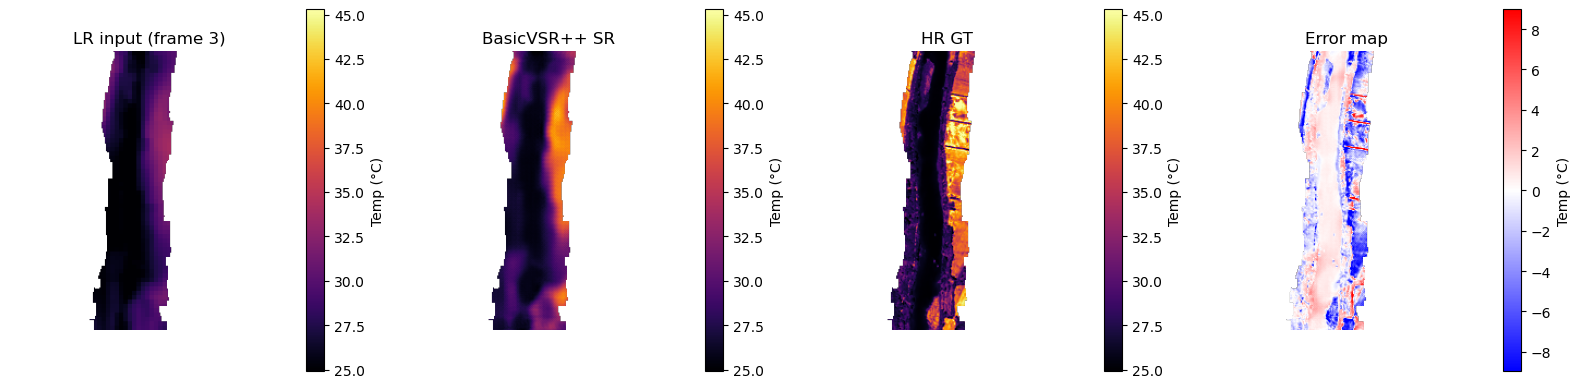

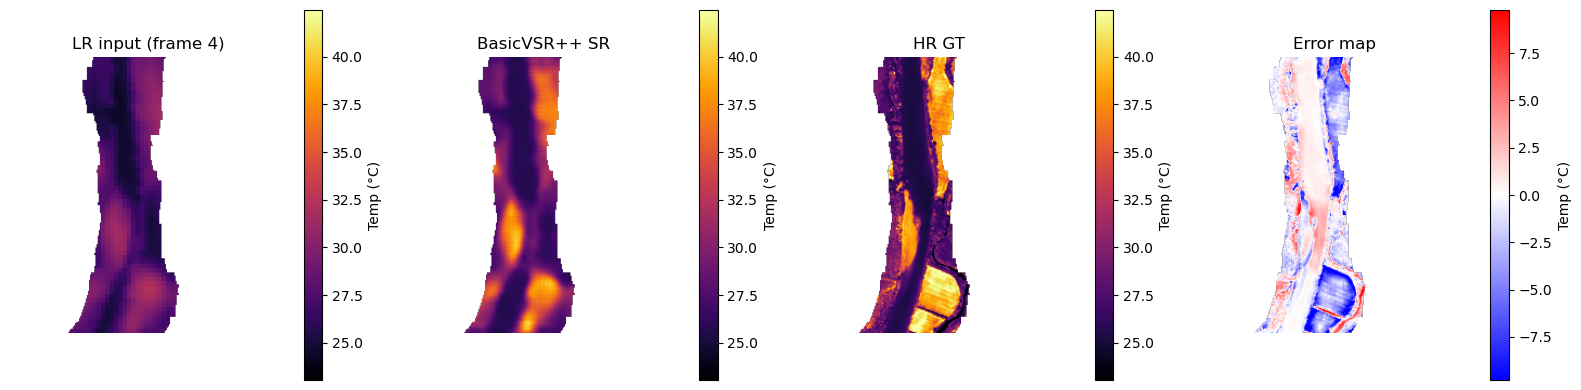

In [20]:
# load validation dataset
val_ds = SRDataset(
    split="val",
    processed_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    augment=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False
)

print("Number of validation sequences:", len(val_ds))

# Select a sequence to visualize
sequence_id = 0

batch = val_ds[sequence_id]

# Add batch dimension for model
lr = batch["lr"].unsqueeze(0).to(device)     # [1,T,C,H,W]

# Keep targets without batch for visualization
hr = batch["hr"].unsqueeze(0).to(device)     # [1,T,C,H,W]
hr_mask = batch["hr_mask"].unsqueeze(0).to(device)

print("LR:", lr.shape)
print("HR:", hr.shape)
print("HR Mask:", hr_mask.shape)

# Run inference
model.eval()

with torch.no_grad():
    sr = model(lr)

# Denormalize
sr = sr.cpu() * HR_STD + HR_MEAN
hr = hr.cpu() * HR_STD + HR_MEAN
lr = lr.cpu() * HR_STD + LR_MEAN
hr_mask = hr_mask.cpu()

# remove batch dimension
lr = lr[0]          # [T,1,64,64]
sr = sr[0]          # [T,1,256,256]
hr = hr[0]          # [T,1,256,256]
mask = hr_mask[0]   # [T,1,256,256]

T = sr.shape[0]

for t in range(T):
    # remove channel
    lr_frame = lr[t,0].numpy()
    sr_frame = sr[t,0].numpy()
    hr_frame = hr[t,0].numpy()

    mask_frame = mask[t,0].numpy() > 0.5

    # Upsample LR to HR grid for visualization
    lr_up = np.repeat(np.repeat(lr_frame, 4, axis=0),4,axis=1)

    # Apply HR validity mask
    lr_vis = np.where(mask_frame, lr_up, np.nan)
    sr_vis = np.where(mask_frame, sr_frame, np.nan)
    hr_vis = np.where(mask_frame, hr_frame, np.nan)

    valid_pixels = hr_vis[np.isfinite(hr_vis)]
    vmin = np.percentile(valid_pixels, 1) #if len(valid_pixels) > 0 else 24.0
    vmax = np.percentile(valid_pixels, 99) #if len(valid_pixels) > 0 else 28.0

    # Error only on valid pixels
    residual = sr_vis -hr_vis
    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(1,4,figsize=(16,4))

    im_lr = ax[0].imshow(lr_vis,cmap="inferno", vmin=vmin, vmax=vmax)
    ax[0].set_title(f"LR input (frame {t})")
    plt.colorbar(im_lr, ax=ax[0], label="Temp (°C)" )

    im_sr = ax[1].imshow(sr_vis,cmap="inferno", vmin=vmin, vmax=vmax)
    ax[1].set_title("BasicVSR++ SR")
    plt.colorbar(im_sr, ax=ax[1], label="Temp (°C)" )

    im_hr = ax[2].imshow(hr_vis,cmap="inferno", vmin=vmin, vmax=vmax)
    ax[2].set_title("HR GT")
    plt.colorbar(im_hr, ax=ax[2], label="Temp (°C)" )

    im_res = ax[3].imshow( residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    ax[3].set_title("Error map")
    plt.colorbar(im_res, ax=ax[3], label="Temp (°C)" )


    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

Number of test sequences: 12
LR: torch.Size([1, 5, 3, 64, 64])
HR: torch.Size([1, 5, 3, 256, 256])
HR Mask: torch.Size([1, 5, 1, 256, 256])


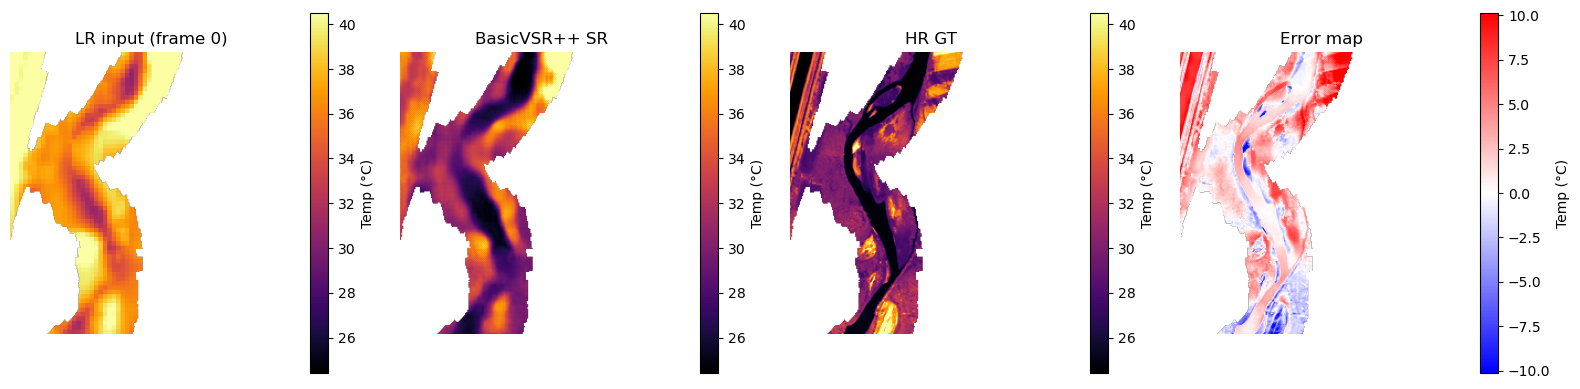

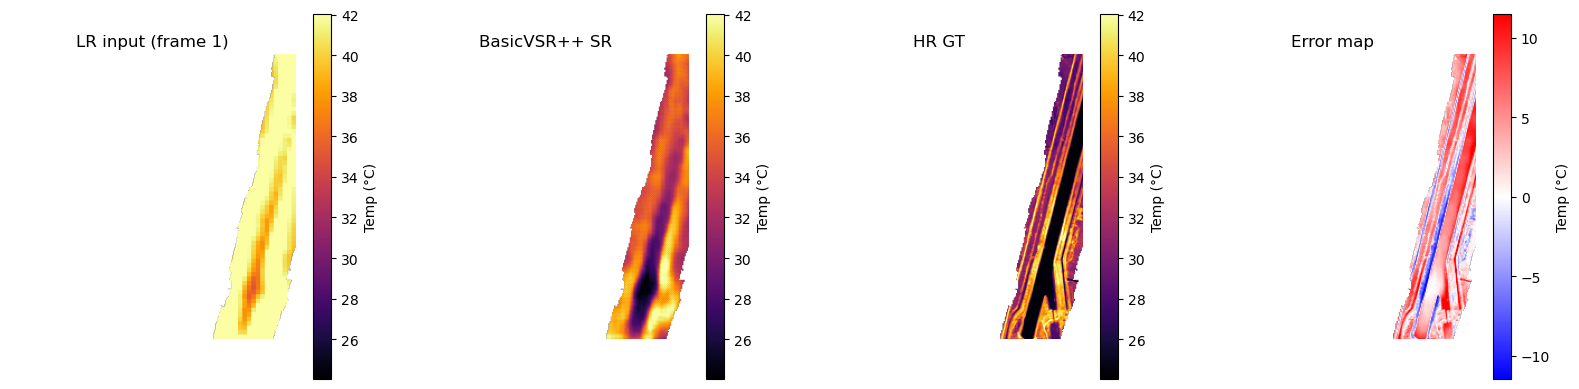

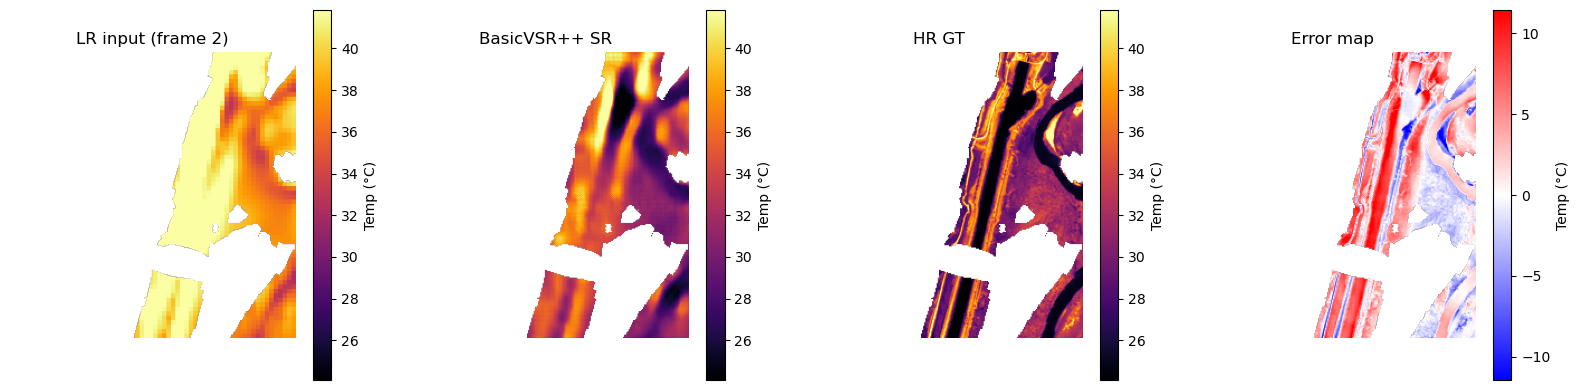

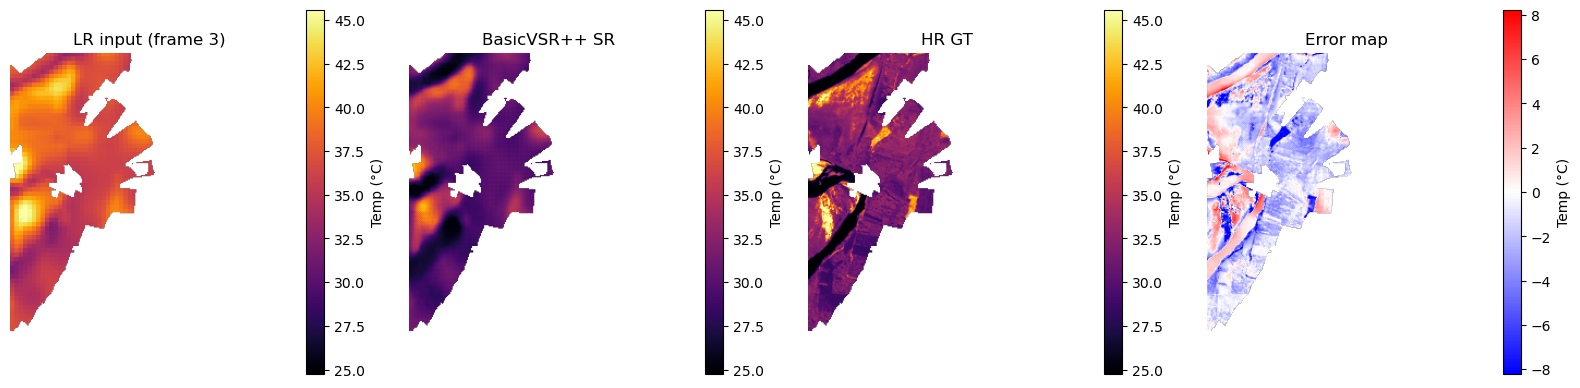

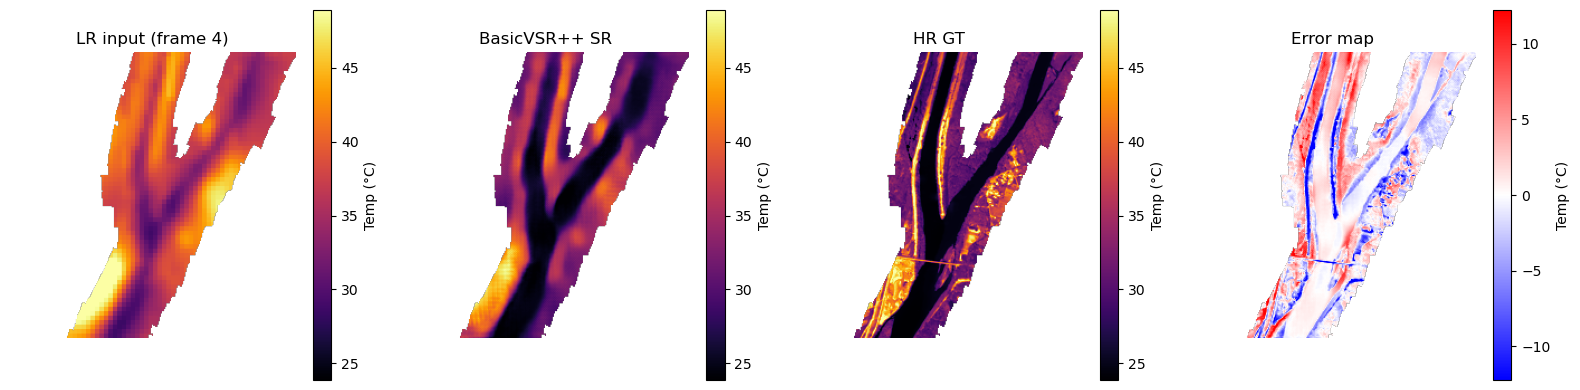

In [22]:
# load test dataset
test_ds = SRDataset(
    split="test",
    processed_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    augment=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False
)

print("Number of test sequences:", len(test_ds))

# Select a sequence to visualize
sequence_id = 5

batch = test_ds[sequence_id]

# Add batch dimension for model
lr = batch["lr"].unsqueeze(0).to(device)     # [1,T,C,H,W]

# Keep targets without batch for visualization
hr = batch["hr"].unsqueeze(0).to(device)     # [1,T,C,H,W]
hr_mask = batch["hr_mask"].unsqueeze(0).to(device)

print("LR:", lr.shape)
print("HR:", hr.shape)
print("HR Mask:", hr_mask.shape)

# Run inference
model.eval()

with torch.no_grad():
    sr = model(lr)

# Denormalize
sr = sr.cpu() * HR_STD + HR_MEAN
hr = hr.cpu() * HR_STD + HR_MEAN
lr = lr.cpu() * HR_STD + LR_MEAN
hr_mask = hr_mask.cpu()

# remove batch dimension
lr = lr[0]          # [T,1,64,64]
sr = sr[0]          # [T,1,256,256]
hr = hr[0]          # [T,1,256,256]
mask = hr_mask[0]   # [T,1,256,256]

T = sr.shape[0]

for t in range(T):
    # remove channel
    lr_frame = lr[t,0].numpy()
    sr_frame = sr[t,0].numpy()
    hr_frame = hr[t,0].numpy()

    mask_frame = mask[t,0].numpy() > 0.5

    # Upsample LR to HR grid for visualization
    lr_up = np.repeat(np.repeat(lr_frame, 4, axis=0),4,axis=1)

    # Apply HR validity mask
    lr_vis = np.where(mask_frame, lr_up, np.nan)
    sr_vis = np.where(mask_frame, sr_frame, np.nan)
    hr_vis = np.where(mask_frame, hr_frame, np.nan)

    valid_pixels = hr_vis[np.isfinite(hr_vis)]
    vmin = np.percentile(valid_pixels, 1) #if len(valid_pixels) > 0 else 24.0
    vmax = np.percentile(valid_pixels, 99) #if len(valid_pixels) > 0 else 28.0

    # Error only on valid pixels
    residual = sr_vis -hr_vis
    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(1,4,figsize=(16,4))

    im_lr = ax[0].imshow(lr_vis,cmap="inferno", vmin=vmin, vmax=vmax)
    ax[0].set_title(f"LR input (frame {t})")
    plt.colorbar(im_lr, ax=ax[0], label="Temp (°C)" )

    im_sr = ax[1].imshow(sr_vis,cmap="inferno", vmin=vmin, vmax=vmax)
    ax[1].set_title("BasicVSR++ SR")
    plt.colorbar(im_sr, ax=ax[1], label="Temp (°C)" )

    im_hr = ax[2].imshow(hr_vis,cmap="inferno", vmin=vmin, vmax=vmax)
    ax[2].set_title("HR GT")
    plt.colorbar(im_hr, ax=ax[2], label="Temp (°C)" )

    im_res = ax[3].imshow( residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    ax[3].set_title("Error map")
    plt.colorbar(im_res, ax=ax[3], label="Temp (°C)" )


    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

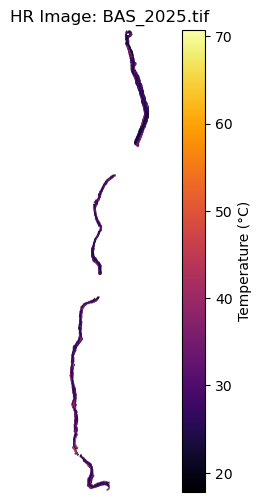

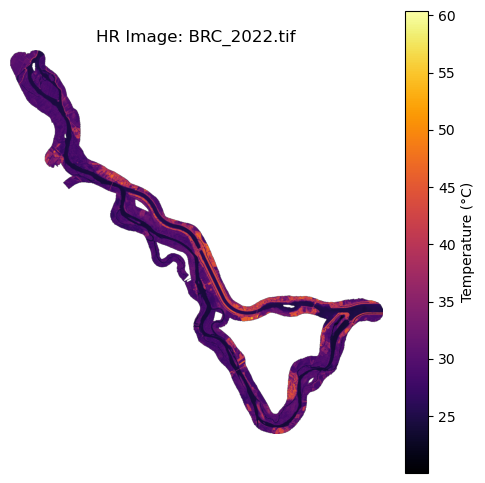

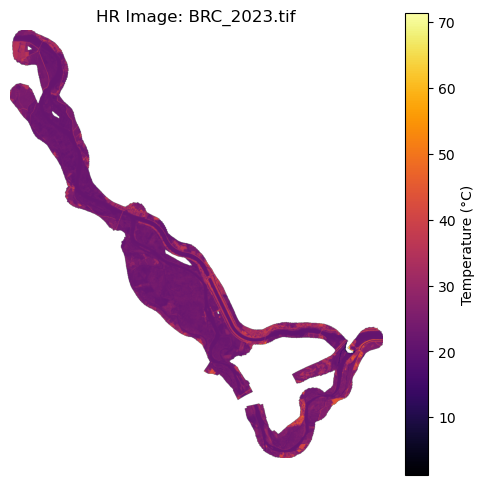

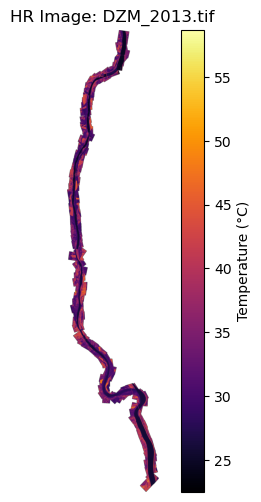

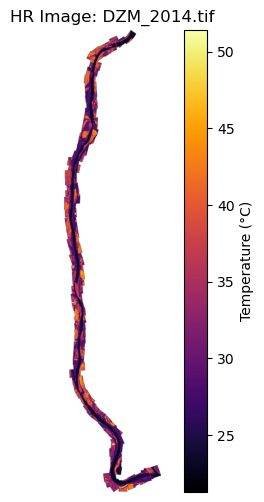

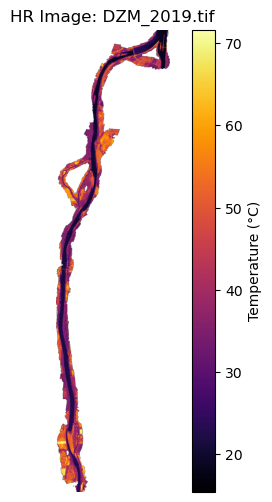

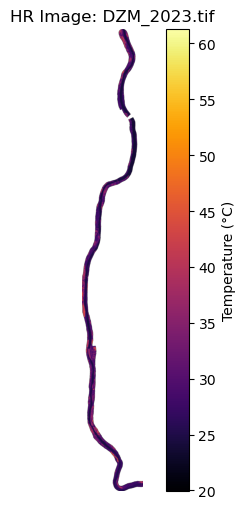

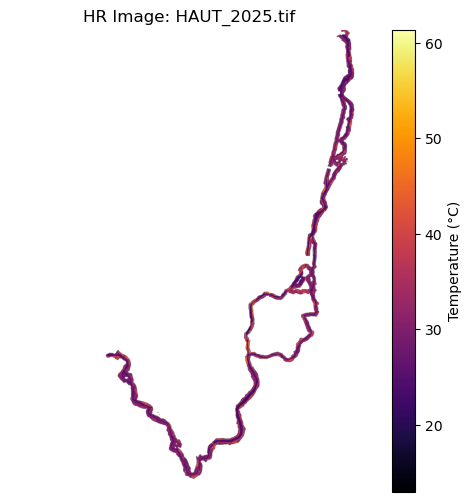

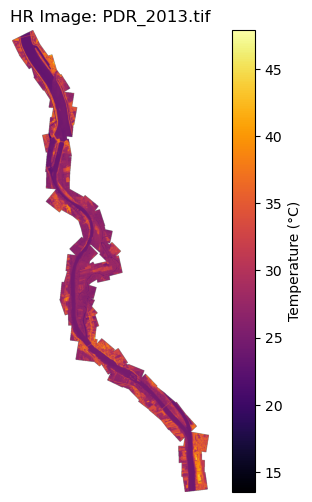

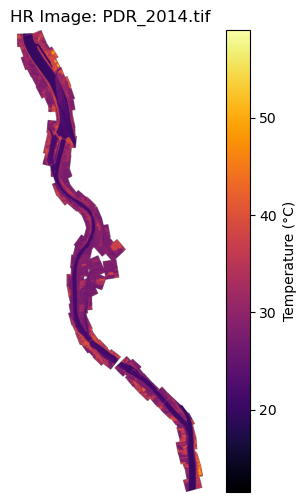

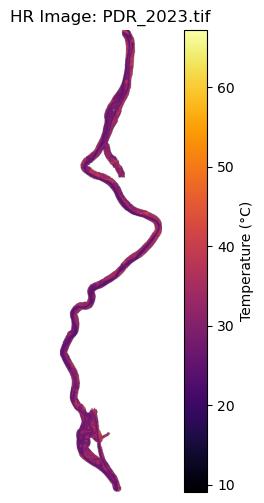

In [5]:
# plot all my HR tifs to see how river looks like
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

HR_FOLDER = "/share/home/e2406751/Superresolution-TIR/data/HR_downsampled"

hr_files = sorted(Path(HR_FOLDER).glob("*.tif"))
for hr_file in hr_files:
    with rasterio.open(hr_file) as src:
        hr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            hr[hr < -1e30] = np.nan


    plt.figure(figsize=(6, 6))
    plt.imshow(hr, cmap="inferno")
    plt.title(f"HR Image: {hr_file.name}")
    plt.colorbar(label="Temperature (°C)")
    plt.axis("off")
    plt.show()

Loading thermal campaign and landcover mask...
Intersecting layers to isolate the river channel within the flight path...


/tmp/ipykernel_155353/3395076679.py:41: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  river_binary = remove_small_objects(river_binary, min_size=100)


Computing centerline via skeletonization...
Generating visualization plots...


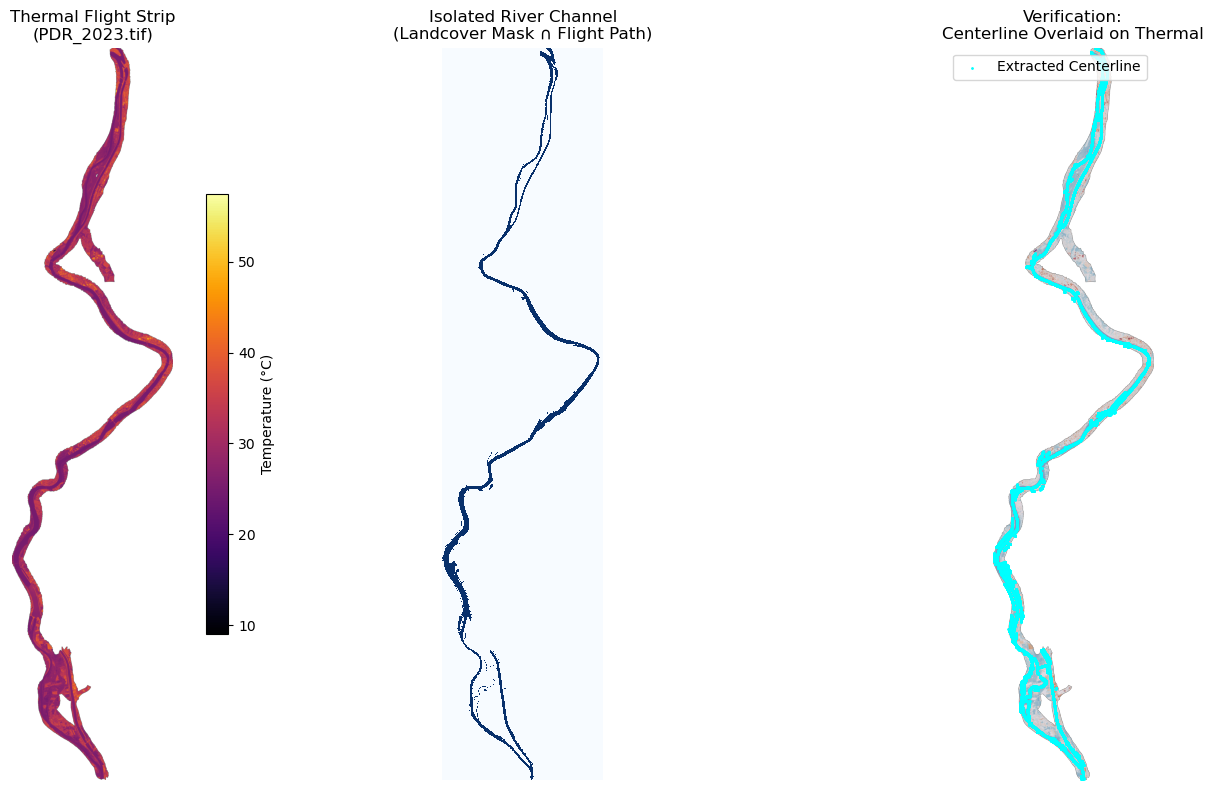

In [7]:
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from skimage.morphology import skeletonize, remove_small_objects
import matplotlib.pyplot as plt

def extract_and_visualize_centerline(thermal_path, landcover_mask_path):
    print("Loading thermal campaign and landcover mask...")
    
    with rasterio.open(thermal_path) as src_thermal:
        thermal_img = src_thermal.read(1)
        thermal_meta = src_thermal.meta
        nodata_val = src_thermal.nodata
        
        # 1. Create a mask of the valid flight path (ignoring the white/nodata background)
        # Handle both standard nodata values and potential NaNs
        if nodata_val is not None:
            flight_path_mask = (thermal_img != nodata_val)
        else:
            flight_path_mask = ~np.isnan(thermal_img)
            
        # Also clean up any extreme edge artifacts if background is pure white (e.g., 255 or max float)
        flight_path_mask &= (thermal_img < np.nanmax(thermal_img) * 0.99)

        # 2. Open landcover water mask and match its geometry to the thermal image
        with rasterio.open(landcover_mask_path) as src_mask:
            # We read and match the exact pixel grid shape of the thermal campaign
            landcover_mask = src_mask.read(
                1, 
                out_shape=(src_thermal.height, src_thermal.width),
                resampling=Resampling.nearest
            )
            
    print("Intersecting layers to isolate the river channel within the flight path...")
    # Assuming water pixels are flagged as 1 in your landcover map (adjust if different, e.g., 255)
    water_pixel_value = 1 
    river_binary = (landcover_mask == water_pixel_value) & flight_path_mask
    
    # Clean up minor fragmentation/noise to ensure a continuous skeleton
    river_binary = remove_small_objects(river_binary, min_size=100)

    print("Computing centerline via skeletonization...")
    # 3. Generate the 1-pixel wide skeleton line
    skeleton = skeletonize(river_binary)
    
    print("Generating visualization plots...")
    # 4. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=True, sharey=True)
    
    # Plot 1: Original Thermal Strip
    # Masking out background for better colormap rendering
    display_thermal = np.where(flight_path_mask, thermal_img, np.nan)
    im1 = axes[0].imshow(display_thermal, cmap='inferno')
    axes[0].set_title(f"Thermal Flight Strip\n({os.path.basename(thermal_path)})", fontsize=12)
    fig.colorbar(im1, ax=axes[0], label="Temperature (°C)", shrink=0.6)
    
    # Plot 2: Clipped Landcover River Boundary
    axes[1].imshow(river_binary, cmap='Blues', interpolation='nearest')
    axes[1].set_title("Isolated River Channel\n(Landcover Mask ∩ Flight Path)", fontsize=12)
    
    # Plot 3: Centerline Overlay on Thermal
    axes[2].imshow(display_thermal, cmap='twilight_shifted')
    # Get y, x indices of the skeleton to plot as a scatter/line overlay
    y_idx, x_idx = np.where(skeleton)
    axes[2].scatter(x_idx, y_idx, color='cyan', s=1, label='Extracted Centerline')
    axes[2].set_title("Verification:\nCenterline Overlaid on Thermal", fontsize=12)
    axes[2].legend(loc='upper right')
    
    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    # Return the skeleton array and metadata if you want to export it later
    return skeleton, thermal_meta

# --- EXECUTE TEST ---
# Replace these filenames with your local paths to run the test
THERMAL_CAMPAIGN = "/share/home/e2406751/Superresolution-TIR/data/HR_downsampled/PDR_2023.tif" 
LANDCOVER_MASK = "/share/home/e2406751/Superresolution-TIR/data/AUX/water_masks/PDR_2023_water_mask.tif" 

if __name__ == "__main__":
    if os.path.exists(THERMAL_CAMPAIGN) and os.path.exists(LANDCOVER_MASK):
        skeleton_mask, meta = extract_and_visualize_centerline(THERMAL_CAMPAIGN, LANDCOVER_MASK)
    else:
        print("Please make sure to update the THERMAL_CAMPAIGN and LANDCOVER_MASK paths with your actual filenames!")

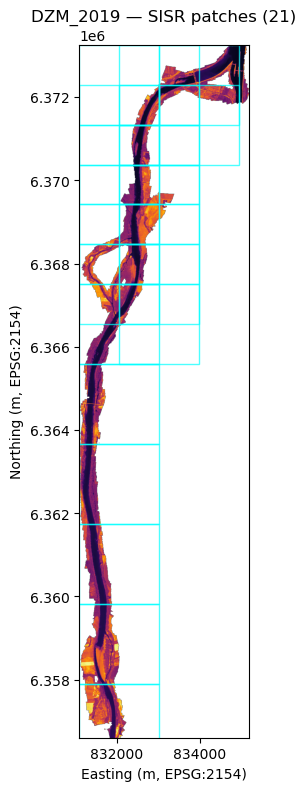

In [49]:
import json
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

hr_path = "/share/home/e2406751/Superresolution-TIR/data/HR_downsampled/DZM_2019.tif"
sisr_meta_path = "/share/home/e2406751/Superresolution-TIR/data/processed/patches2/metadata.json"
campaign = "DZM_2019"

with rasterio.open(hr_path) as src:
    arr = src.read(1, masked=True)
    b = src.bounds
    extent = (b.left, b.right, b.bottom, b.top)

with open(sisr_meta_path) as f:
    sisr_meta = json.load(f)

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(arr, cmap="inferno", extent=extent, origin="upper")

n = 0
for key, entry in sisr_meta.items():
    if entry.get("campaign") != campaign:
        continue
    bd = entry["bounds_2154"]
    w, h = bd["right"] - bd["left"], bd["top"] - bd["bottom"]
    ax.add_patch(Rectangle((bd["left"], bd["bottom"]), w, h,
                            linewidth=1.0, edgecolor="cyan", facecolor="none", alpha=0.7))
    n += 1

ax.set_title(f"{campaign} — SISR patches ({n})")
ax.set_xlabel("Easting (m, EPSG:2154)")
ax.set_ylabel("Northing (m, EPSG:2154)")
ax.set_aspect("equal")
plt.show()

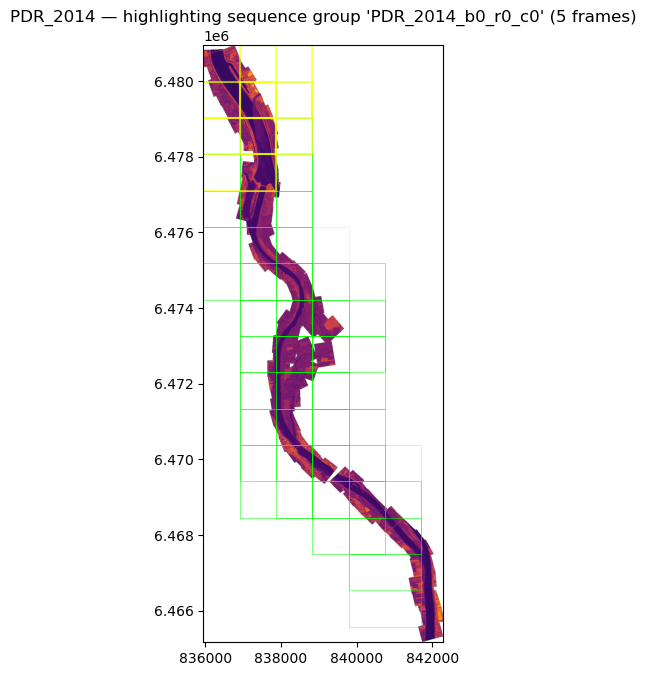

In [41]:
import json
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

hr_path = "/share/home/e2406751/Superresolution-TIR/data/HR_downsampled/PDR_2014.tif"
seq_meta_path = "/share/home/e2406751/Superresolution-TIR/data/processed/seq_patches/metadata.json"
patches_dir = "/share/home/e2406751/Superresolution-TIR/data/processed/seq_patches/val/HR"
campaign = "PDR_2014"
sequence_group = "PDR_2014_b0_r0_c0"   # change this to inspect a different group

# --- load HR campaign raster ---
with rasterio.open(hr_path) as src:
    arr = src.read(1, masked=True)
    b = src.bounds
    extent = (b.left, b.right, b.bottom, b.top)

# --- load metadata, split into "this group" vs "everything else" ---
with open(seq_meta_path) as f:
    seq_meta = json.load(f)

group_entries = {k: v for k, v in seq_meta.items()
                  if v.get("campaign") == campaign and v.get("sequence_group") == sequence_group}
other_entries = {k: v for k, v in seq_meta.items()
                  if v.get("campaign") == campaign and v.get("sequence_group") != sequence_group}

group_entries = dict(sorted(group_entries.items(), key=lambda kv: kv[1]["frame_index"]))
n_frames = len(group_entries)

# --- load actual frame patch arrays ---
frame_dir = f"{patches_dir}/{sequence_group}"
frame_files = sorted(glob.glob(f"{frame_dir}/*.npy"))
frames = [np.load(fp) for fp in frame_files]

# --- figure: campaign+overlay | frame strip below ---
fig = plt.figure(figsize=(4 * max(n_frames, 1), 9))
gs = fig.add_gridspec(2, max(n_frames, 1), height_ratios=[3, 1])

# top: full campaign, all other groups faint, this group highlighted
ax_map = fig.add_subplot(gs[0, :])
ax_map.imshow(arr, cmap="inferno", extent=extent, origin="upper")

for entry in other_entries.values():
    bd = entry["bounds_2154"]
    w, h = bd["right"] - bd["left"], bd["top"] - bd["bottom"]
    ax_map.add_patch(Rectangle((bd["left"], bd["bottom"]), w, h,
                                linewidth=0.6, edgecolor="lime", facecolor="none", alpha=0.15))

for entry in group_entries.values():
    bd = entry["bounds_2154"]
    w, h = bd["right"] - bd["left"], bd["top"] - bd["bottom"]
    ax_map.add_patch(Rectangle((bd["left"], bd["bottom"]), w, h,
                                linewidth=1.5, edgecolor="yellow", facecolor="none", alpha=0.6))

ax_map.set_title(f"{campaign} — highlighting sequence group '{sequence_group}' ({n_frames} frames)")
ax_map.set_aspect("equal")

# bottom: each frame patch as a thumbnail
for i, fr in enumerate(frames):
    ax = fig.add_subplot(gs[1, i])
    fr2d = fr.squeeze() if fr.ndim > 2 else fr
    ax.imshow(fr2d, cmap="inferno")
    ax.set_title(f"frame {i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()